# Text Distribution & Concept Gap Analysis
## For Music Caption Datasets (Three-way Comparison)

This notebook analyzes semantic and conceptual differences between three datasets of music captions:
- dataset1_captions: List[str]
- dataset2_captions: List[str]
- dataset3_captions: List[str]

It performs semantic coverage analysis and identifies missing high-level concepts across all three datasets.

In [1]:
!pip install sentence-transformers bertopic umap-learn scikit-learn matplotlib seaborn pandas

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 73.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 210.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 694.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 135.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [bertopic]/14 [bertopic]b]


In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
from bertopic import BERTopic
import umap
import seaborn as sns

In [ ]:
!ls /path/to/discotube/

data  discotube  logs  ollama  vllm


In [8]:
# Dataset names for plots and labels
dataset_1_name = "AllMusic"
dataset_2_name = "MusicCaps"
dataset_3_name = "Song Describer"

In [ ]:
import json
from tqdm import tqdm

text_file = "/path/to/discotube/metadata/Qwen_Qwen2.5-32B__chatgpt_v2__t0.5__1.1.jsonl"
text = dict()
ids_list = []
caps_dataset1 = []
with open(text_file, "r") as f:
    for line in tqdm(f, desc="Loading text data"):
        entry = json.loads(line)
        for k, v in entry.items():
            try:
                sentences = []
                for s in v.values():
                    sentences.extend(s)
                text[k] = " ".join(sentences)
                ids_list.append(k)
                caps_dataset1.append(text[k])
            except Exception as e:
                pass
                # print(f"Error processing entry {k}: {e}")

print(f"Loaded {len(text)} text entries for {dataset_1_name}")

Loading text data: 247118it [00:01, 223000.21it/s]

Loaded 242913 text entries for Dataset 1


In [ ]:
# Load MusicCaps data (Dataset 2)
from datasets import load_dataset

dataset = load_dataset("seungheondoh/LP-MusicCaps-MC")

caps_dataset2 = list(dataset["test"]["caption_ground_truth"])

# Load Dataset 3 (replace with your actual dataset)
# Example: dataset3 = load_dataset("your-dataset-name")
caps_dataset3 = load_dataset("seungheondoh/eval-song_describer")

dataset = caps_dataset3["original"]
dataset = pd.DataFrame(dataset)
dataset = dataset[dataset["is_valid_subset"]]

caps_dataset3 = list(dataset["caption"])
print(f"{dataset_2_name} loaded: {len(caps_dataset2)} captions")
print(f"{dataset_3_name} loaded: {len(caps_dataset3)} captions")

Dataset 2 loaded: 2858 captions
Dataset 3 loaded: 746 captions


In [10]:
import random

random.seed(42)
random.shuffle(caps_dataset1)

# Subsample datasets for comparison
dataset1_captions = caps_dataset1[:5000]
dataset2_captions = caps_dataset2
dataset3_captions = caps_dataset3  # Uncomment when dataset 3 is loaded

print(f"{dataset_1_name} samples: {len(dataset1_captions)}")
print(f"{dataset_2_name} samples: {len(dataset2_captions)}")
print(f"{dataset_3_name} samples: {len(dataset3_captions)}")

AllMusic samples: 5000
MusicCaps samples: 2858
Song Describer samples: 746


In [11]:
def basic_stats(captions):
    tokens = [w for c in captions for w in c.split()]
    return {
        "num_samples": len(captions),
        "vocab_size": len(set(tokens)),
        "avg_len": np.mean([len(c.split()) for c in captions]),
        "type_token_ratio": len(set(tokens)) / len(tokens),
    }


print(f"{dataset_1_name} Stats:", basic_stats(dataset1_captions))
print(f"{dataset_2_name} Stats:", basic_stats(dataset2_captions))
print(f"{dataset_3_name} Stats:", basic_stats(dataset3_captions))

AllMusic Stats: {'num_samples': 5000, 'vocab_size': 17653, 'avg_len': np.float64(32.1982), 'type_token_ratio': 0.10965209235298867}
MusicCaps Stats: {'num_samples': 2858, 'vocab_size': 7449, 'avg_len': np.float64(50.907977606717985), 'type_token_ratio': 0.05119763565758274}
Song Describer Stats: {'num_samples': 746, 'vocab_size': 2483, 'avg_len': np.float64(16.82171581769437), 'type_token_ratio': 0.1978643716630807}


In [ ]:
model = SentenceTransformer("all-mpnet-base-v2", device="cuda")
emb_d1 = model.encode(
    dataset1_captions, normalize_embeddings=True, show_progress_bar=True
)
emb_d2 = model.encode(
    dataset2_captions, normalize_embeddings=True, show_progress_bar=True
)
emb_d3 = model.encode(
    dataset3_captions, normalize_embeddings=True, show_progress_bar=True
)

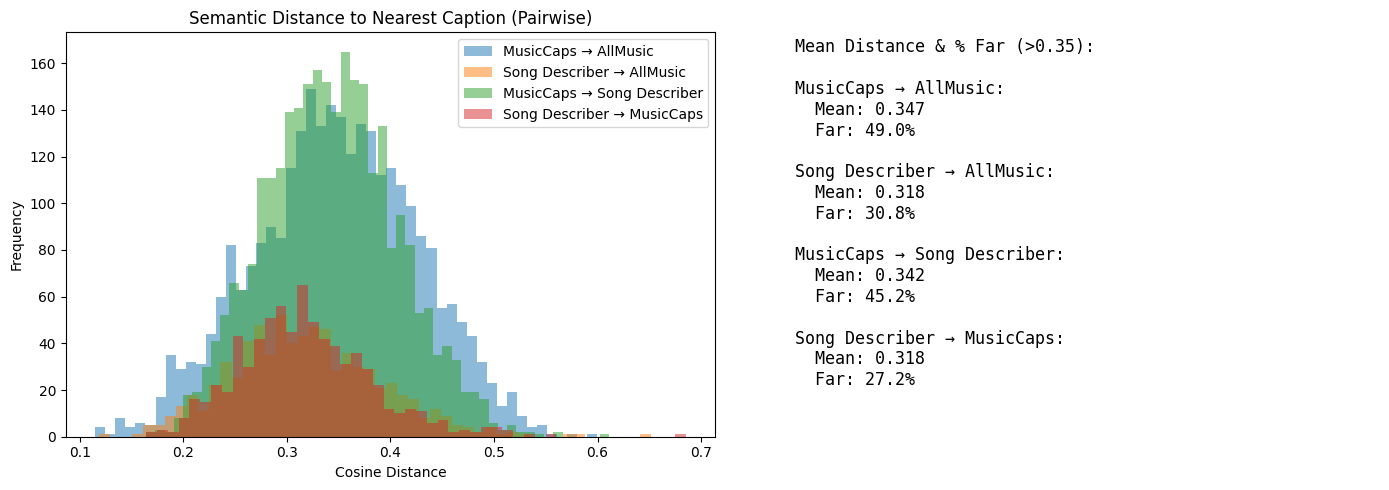

In [16]:
# Dataset 2 to Dataset 1
dist_matrix_d2_d1 = cosine_distances(emb_d2, emb_d1)
min_dist_d2 = dist_matrix_d2_d1.min(axis=1)

# Dataset 3 to Dataset 1
dist_matrix_d3_d1 = cosine_distances(emb_d3, emb_d1)
min_dist_d3 = dist_matrix_d3_d1.min(axis=1)

# Dataset 2 to Dataset 3
dist_matrix_d2_d3 = cosine_distances(emb_d2, emb_d3)
min_dist_d2d3 = dist_matrix_d2_d3.min(axis=1)

# Dataset 3 to Dataset 2
dist_matrix_d3_d2 = cosine_distances(emb_d3, emb_d2)
min_dist_d3d2 = dist_matrix_d3_d2.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    min_dist_d2, bins=50, alpha=0.5, label=f"{dataset_2_name} → {dataset_1_name}"
)
axes[0].hist(
    min_dist_d3, bins=50, alpha=0.5, label=f"{dataset_3_name} → {dataset_1_name}"
)
axes[0].hist(
    min_dist_d2d3, bins=50, alpha=0.5, label=f"{dataset_2_name} → {dataset_3_name}"
)
axes[0].hist(
    min_dist_d3d2, bins=50, alpha=0.5, label=f"{dataset_3_name} → {dataset_2_name}"
)
axes[0].set_title("Semantic Distance to Nearest Caption (Pairwise)")
axes[0].set_xlabel("Cosine Distance")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Summary statistics
stats_data = {
    f"{dataset_2_name} → {dataset_1_name}": [
        np.mean(min_dist_d2),
        np.mean(min_dist_d2 > 0.35) * 100,
    ],
    f"{dataset_3_name} → {dataset_1_name}": [
        np.mean(min_dist_d3),
        np.mean(min_dist_d3 > 0.35) * 100,
    ],
    f"{dataset_2_name} → {dataset_3_name}": [
        np.mean(min_dist_d2d3),
        np.mean(min_dist_d2d3 > 0.35) * 100,
    ],
    f"{dataset_3_name} → {dataset_2_name}": [
        np.mean(min_dist_d3d2),
        np.mean(min_dist_d3d2 > 0.35) * 100,
    ],
}

axes[1].axis("off")
stats_text = "Mean Distance & % Far (>0.35):\n\n"
for label, (mean_d, pct_far) in stats_data.items():
    stats_text += f"{label}:\n  Mean: {mean_d:.3f}\n  Far: {pct_far:.1f}%\n\n"

axes[1].text(
    0.1, 0.5, stats_text, fontsize=12, verticalalignment="center", family="monospace"
)


plt.tight_layout()
plt.show()

In [17]:
# Far captions Dataset 2 to Dataset 1
min_dist = dist_matrix_d2_d1.min(axis=1)
far_indices = np.where(min_dist > 0.35)[0]
print(f"Examples of far Captions in {dataset_2_name} (compared to {dataset_1_name}):")
for idx in far_indices[:5]:
    print("\n-", dataset2_captions[idx])

# Far captions Dataset 3 to Dataset 2
min_dist = dist_matrix_d3_d1.min(axis=1)
far_indices = np.where(min_dist > 0.35)[0]
print(
    f"\n\nExamples of far Captions in {dataset_3_name} (compared to {dataset_1_name}):"
)
for idx in far_indices[:5]:
    print("\n-", dataset3_captions[idx])

# Far captions Dataset 2 to Dataset 3
min_dist = dist_matrix_d2_d3.min(axis=1)
far_indices = np.where(min_dist > 0.35)[0]
print(
    f"\n\nExamples of far Captions in {dataset_2_name} (compared to {dataset_3_name}):"
)
for idx in far_indices[:5]:
    print("\n-", dataset2_captions[idx])

# Far captions Dataset 2 to Dataset 3
min_dist = dist_matrix_d3_d2.min(axis=1)
far_indices = np.where(min_dist > 0.35)[0]
print(
    f"\n\nExamples of far Captions in {dataset_3_name} (compared to {dataset_2_name}):"
)
for idx in far_indices[:5]:
    print("\n-", dataset2_captions[idx])

Examples of far Captions in MusicCaps (compared to AllMusic):

- a male voice is singing a melody with changing tempos while snipping his fingers rhythmically. The recording sounds like it has been recorded in an empty room. This song may be playing, practicing snipping and singing along.

- This song contains digital drums playing a simple groove along with two guitars. One strumming chords along with the snare the other one playing a melody on top. An e-bass is playing the footnote while a piano is playing a major and minor chord progression. A trumpet is playing a loud melody alongside the guitar. All the instruments sound flat and are being played by a keyboard. There are little bongo hits in the background panned to the left side of the speakers. Apart from the music you can hear eating sounds and a stomach rumbling. This song may be playing for an advertisement.

- A male singer sings this groovy melody. The song is a techno dance song with a groovy bass line, strong drumming rhy

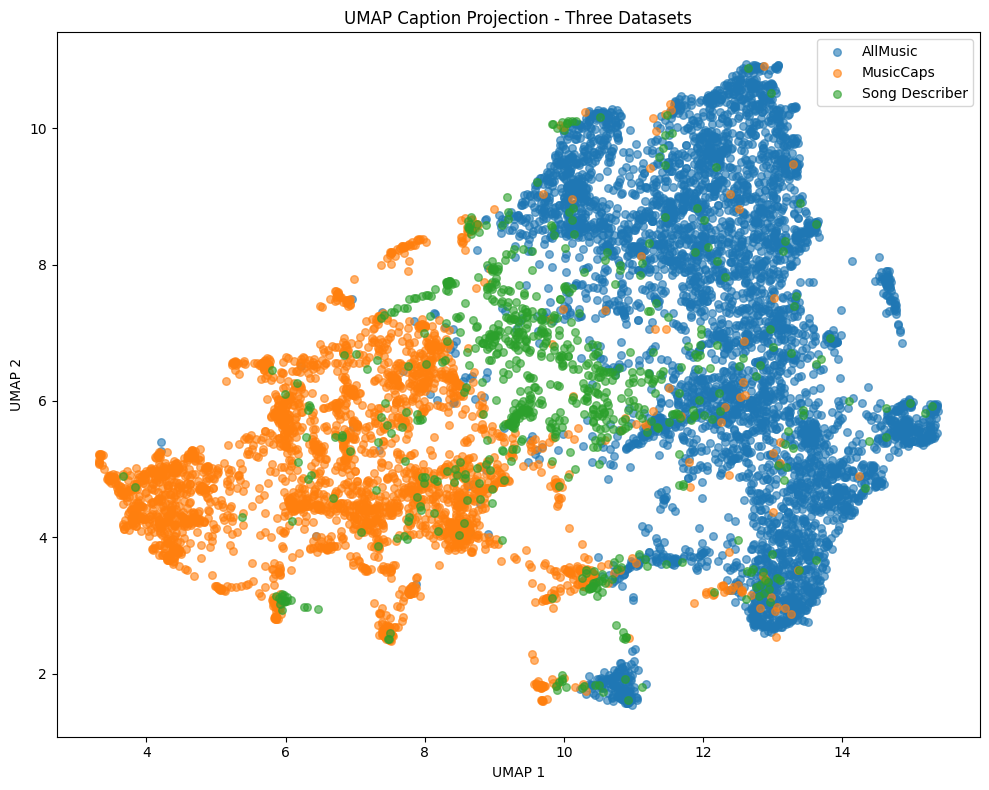

In [18]:
combined = np.vstack([emb_d1, emb_d2, emb_d3])
labels = np.array([0] * len(emb_d1) + [1] * len(emb_d2) + [2] * len(emb_d3))

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine")
projection = umap_model.fit_transform(combined)

plt.figure(figsize=(10, 8))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
dataset_names = [dataset_1_name, dataset_2_name, dataset_3_name]

for i, name in enumerate(dataset_names):
    mask = labels == i
    plt.scatter(
        projection[mask, 0],
        projection[mask, 1],
        label=name,
        alpha=0.6,
        c=colors[i],
        s=30,
    )

plt.legend()
plt.title("UMAP Caption Projection - Three Datasets")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

In [27]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

# Fit on all datasets combined
all_for_vocab = dataset1_captions + dataset2_captions + dataset3_captions
vectorizer.fit(all_for_vocab)

X_d1 = vectorizer.transform(dataset1_captions)
X_d2 = vectorizer.transform(dataset2_captions)
X_d3 = vectorizer.transform(dataset3_captions)

terms = np.array(vectorizer.get_feature_names_out())

# Compare Dataset 2 vs Dataset 1
diff_d2_d1 = X_d2.mean(axis=0).A1 - X_d1.mean(axis=0).A1
idx_d2 = np.argsort(diff_d2_d1)[::-1]

print(f"Top terms in {dataset_2_name} (vs {dataset_1_name}):")
print(terms[idx_d2[:30]])

# Compare Dataset 3 vs Dataset 1
diff_d3_d1 = X_d3.mean(axis=0).A1 - X_d1.mean(axis=0).A1
idx_d3 = np.argsort(diff_d3_d1)[::-1]

print(f"\nTop terms in {dataset_3_name} (vs {dataset_1_name}):")
print(terms[idx_d3[:30]])

# Compare Dataset 3 vs Dataset 2
diff_d3_d2 = X_d3.mean(axis=0).A1 - X_d2.mean(axis=0).A1
idx_d3 = np.argsort(diff_d3_d2)[::-1]

print(f"\nTop terms in {dataset_3_name} (vs {dataset_2_name}):")
print(terms[idx_d3[:30]])

Top terms in MusicCaps (vs AllMusic):
['playing' 'song' 'melody' 'recording' 'male' 'guitar' 'quality'
 'background' 'bass' 'low' 'singing' 'played' 'sounds' 'female' 'voice'
 'medium' 'groovy' 'instrumental' 'tempo' 'audio' 'piece' 'harmony'
 'chords' 'electric' 'used' 'consists' 'sings' 'vocalist' 'accompaniment'
 'drum']

Top terms in Song Describer (vs AllMusic):
['song' 'male' 'piano' 'guitar' 'instrumental' 'voice' 'french' 'drums'
 'female' 'beat' 'sad' 'positive' 'solo' 'makes' 'vocals' 'singer'
 'starts' 'relaxing' 'melody' 'chorus' 'riff' 'electric' 'acoustic' 'sung'
 'spanish' 'piece' 'happy' 'intro' 'calm' 'played']

Top terms in Song Describer (vs MusicCaps):
['track' 'piano' 'featuring' 'french' 'vocals' 'rock' 'pop' 'positive'
 'guitars' 'feel' 'vibe' 'electronic' 'makes' 'lyrics' 'chorus' 'sad'
 'later' 'love' 'drums' 'synths' 'driving' 'calm' 'indie' 'spanish'
 'upbeat' 'builds' 'perfect' 'intro' 'base' 'based']


In [29]:
all_captions = dataset1_captions + dataset2_captions + dataset3_captions
labels_dataset = (
    ["dataset1"] * len(dataset1_captions)
    + ["dataset2"] * len(dataset2_captions)
    + ["dataset3"] * len(dataset3_captions)
)

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(all_captions)

df_topics = pd.DataFrame(
    {"caption": all_captions, "topic": topics, "dataset": labels_dataset}
)

d1_dist = df_topics[df_topics.dataset == "dataset1"].topic.value_counts(normalize=True)
d2_dist = df_topics[df_topics.dataset == "dataset2"].topic.value_counts(normalize=True)
d3_dist = df_topics[df_topics.dataset == "dataset3"].topic.value_counts(normalize=True)

concept_gap = []
all_topics = set(d1_dist.index).union(d2_dist.index).union(d3_dist.index)
for t in all_topics:
    d1_pct = d1_dist.get(t, 0)
    d2_pct = d2_dist.get(t, 0)
    d3_pct = d3_dist.get(t, 0)
    gap_d2_d1 = d2_pct - d1_pct
    gap_d3_d2 = d3_pct - d2_pct
    concept_gap.append((t, d1_pct, d2_pct, d3_pct, gap_d2_d1, gap_d3_d2))

concept_gap_df = pd.DataFrame(
    concept_gap,
    columns=[
        "Topic",
        f"{dataset_1_name}%",
        f"{dataset_2_name}%",
        f"{dataset_3_name}%",
        f"Gap({dataset_2_name}-{dataset_1_name})",
        f"Gap({dataset_3_name}-{dataset_2_name})",
    ],
)
concept_gap_df = concept_gap_df.sort_values(
    f"Gap({dataset_2_name}-{dataset_1_name})", ascending=False
)
print(concept_gap_df.head(10))

    Topic  AllMusic%  MusicCaps%  Song Describer%  Gap(MusicCaps-AllMusic)  \
1       1     0.0018    0.194542         0.005362                 0.192742   
7       7     0.0004    0.046886         0.002681                 0.046486   
6       6     0.0038    0.039888         0.012064                 0.036088   
8       8     0.0006    0.033940         0.006702                 0.033340   
16     16     0.0000    0.025192         0.001340                 0.025192   
15     15     0.0006    0.023443         0.004021                 0.022843   
21     21     0.0000    0.020994         0.000000                 0.020994   
25     25     0.0002    0.017145         0.000000                 0.016945   
23     23     0.0006    0.016795         0.002681                 0.016195   
34     34     0.0000    0.013996         0.001340                 0.013996   

    Gap(Song Describer-MusicCaps)  
1                       -0.189180  
7                       -0.044205  
6                       -0.027824

In [30]:
# Build interpretable concept gap table with topic keywords

concept_gap = []

all_topics = set(d1_dist.index).union(d2_dist.index).union(d3_dist.index)
for t in all_topics:
    d1_pct = d1_dist.get(t, 0)
    d2_pct = d2_dist.get(t, 0)
    d3_pct = d3_dist.get(t, 0)
    gap_d2_d1 = d2_pct - d1_pct
    gap_d3_d2 = d3_pct - d2_pct

    # Get human-readable topic representation
    if t == -1:
        topic_label = "Outlier / Noise"
    else:
        words = topic_model.get_topic(t)
        topic_label = ", ".join([w for w, _ in words[:5]])

    concept_gap.append((t, topic_label, d1_pct, d2_pct, d3_pct, gap_d2_d1, gap_d3_d2))

concept_gap_df = pd.DataFrame(
    concept_gap,
    columns=[
        "Topic ID",
        "Topic Keywords",
        f"{dataset_1_name} %",
        f"{dataset_2_name} %",
        f"{dataset_3_name} %",
        f"Gap ({dataset_2_name}-{dataset_1_name})",
        f"Gap ({dataset_3_name}-{dataset_2_name})",
    ],
)

concept_gap_df = concept_gap_df.sort_values(
    f"Gap ({dataset_2_name}-{dataset_1_name})", ascending=False
)

print(f"Interpretable Concept Gap Table (All Three Datasets):")

# do not print index and Topic ID. Only 3 digits
concept_gap_df_display = concept_gap_df.drop(columns=["Topic ID"])
print(
    concept_gap_df_display.head(10).to_string(index=False, float_format="{:.2f}".format)
)

# Add similar analysis for Dataset 3 when ready

Interpretable Concept Gap Table (All Three Datasets):
                               Topic Keywords  AllMusic %  MusicCaps %  Song Describer %  Gap (MusicCaps-AllMusic)  Gap (Song Describer-MusicCaps)
        low, recording, quality, it, consists        0.00         0.19              0.01                      0.19                           -0.19
      medium, instrumental, song, audio, poor        0.00         0.05              0.00                      0.05                           -0.04
         music, instrumental, tempo, fast, is        0.00         0.04              0.01                      0.04                           -0.03
sings, drumming, vocalist, enthusiastic, male        0.00         0.03              0.01                      0.03                           -0.03
          playing, eguitar, ebass, along, may        0.00         0.03              0.00                      0.03                           -0.02
 sings, female, accompaniment, vocalist, song        0.00       